In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/merged/panel_with_controls_1992_2024_pre_oda_floor.csv')
print(df.shape)
print(df.dtypes)
df.head()

(115640, 14)
sender_iso3             object
recipient_iso3          object
year                     int64
arms_tiv               float64
bilateral_oda          float64
econ_neocol_score      float64
colonial_tie             int64
journalist_killings      int64
gdp_per_capita         float64
gdp_per_capita_log     float64
population             float64
population_log         float64
armed_conflict         float64
conflict_intensity     float64
dtype: object


,sender_iso3,recipient_iso3,year,arms_tiv,bilateral_oda,econ_neocol_score,colonial_tie,journalist_killings,gdp_per_capita,gdp_per_capita_log,population,population_log,armed_conflict,conflict_intensity
0,ABW,ISR,1996,17.80,NaN,NaN,0,0,20224.278908,9.914639,5692000.0,15.554572,1.0,1.0
1,AGO,CIV,2002,1.72,NaN,0.000000e+00,0,0,967.815864,6.875042,18654771.0,16.741612,1.0,1.0
2,ALB,BFA,2011,1.20,NaN,7.020872e-12,0,0,725.024768,6.586206,16661908.0,16.628636,0.0,0.0
3,ARE,BFA,2023,3.97,1.279386,3.673185e-08,0,0,873.482590,6.772488,23025776.0,16.952125,1.0,2.0
4,ARE,BGR,2021,0.72,NaN,0.000000e+00,0,0,12966.145754,9.470097,6507301.0,15.688435,0.0,0.0


In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing': missing, 'pct': missing_pct}).query('missing > 0').sort_values('pct', ascending=False)

,missing,pct
econ_neocol_score,35181,30.42
bilateral_oda,11801,10.20
gdp_per_capita,2751,2.38
gdp_per_capita_log,2751,2.38
population,733,0.63
population_log,733,0.63
armed_conflict,644,0.56
conflict_intensity,644,0.56


In [6]:
print(df['journalist_killings'].describe())
print(f"\nZeros: {(df['journalist_killings'] == 0).sum():,} ({(df['journalist_killings'] == 0).mean()*100:.1f}%)")
print(f"Mean: {df['journalist_killings'].mean():.4f}")
print(f"Variance: {df['journalist_killings'].var():.4f}")
print(f"Variance/Mean ratio: {df['journalist_killings'].var() / df['journalist_killings'].mean():.1f}x")

df['journalist_killings'].value_counts().head(10).sort_index()

count    115640.000000
mean          0.566768
std           2.569590
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          82.000000
Name: journalist_killings, dtype: float64

Zeros: 96,316 (83.3%)
Mean: 0.5668
Variance: 6.6028
Variance/Mean ratio: 11.6x


journalist_killings
0    96316
1     8906
2     3666
3     2382
4      741
5      618
6      627
7      449
8      431
9      382
Name: count, dtype: int64

In [7]:
cols = ['arms_tiv', 'bilateral_oda', 'econ_neocol_score']
for col in cols:
    print(f"\n--- {col} ---")
    print(df[col].describe())
    print(f"Zeros: {(df[col] == 0).sum():,} ({(df[col] == 0).mean()*100:.1f}%)")


--- arms_tiv ---
count    115640.000000
mean          7.254507
std          68.669320
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        3895.200000
Name: arms_tiv, dtype: float64
Zeros: 103,514 (89.5%)

--- bilateral_oda ---
count    103839.000000
mean         17.275639
std         123.624815
min       -1206.340000
25%           0.075692
50%           0.807783
75%           7.320000
max       11790.044351
Name: bilateral_oda, dtype: float64
Zeros: 0 (0.0%)

--- econ_neocol_score ---
count    8.045900e+04
mean     2.747605e-08
std      2.086036e-07
min      0.000000e+00
25%      6.004668e-10
50%      3.330933e-09
75%      1.451338e-08
max      3.547826e-05
Name: econ_neocol_score, dtype: float64
Zeros: 4,310 (3.7%)


In [8]:
cols = ['gdp_per_capita', 'gdp_per_capita_log', 'population', 'population_log', 'armed_conflict', 'conflict_intensity']
df[cols].describe()

,gdp_per_capita,gdp_per_capita_log,population,population_log,armed_conflict,conflict_intensity
count,112889.000000,112889.000000,1.149070e+05,114907.000000,114996.000000,114996.000000
mean,4633.153129,7.630084,5.209441e+07,16.103819,0.243948,0.309715
std,8310.165014,1.265655,1.778190e+08,1.908689,0.429463,0.587648
min,30.253901,3.409625,9.038000e+03,9.109193,0.000000,0.000000
25%,792.165700,6.674771,3.524788e+06,15.075331,0.000000,0.000000
50%,2070.412734,7.635503,1.112217e+07,16.224451,0.000000,0.000000
75%,5097.531069,8.536512,3.157809e+07,17.267974,0.000000,0.000000
max,137781.681659,11.833426,1.450936e+09,21.095475,1.000000,2.000000


In [9]:
print(df['colonial_tie'].value_counts())
print(f"\ncolonial_tie=1: {df['colonial_tie'].mean()*100:.1f}% of dyads")

colonial_tie
0    111273
1      4367
Name: count, dtype: int64

colonial_tie=1: 3.8% of dyads


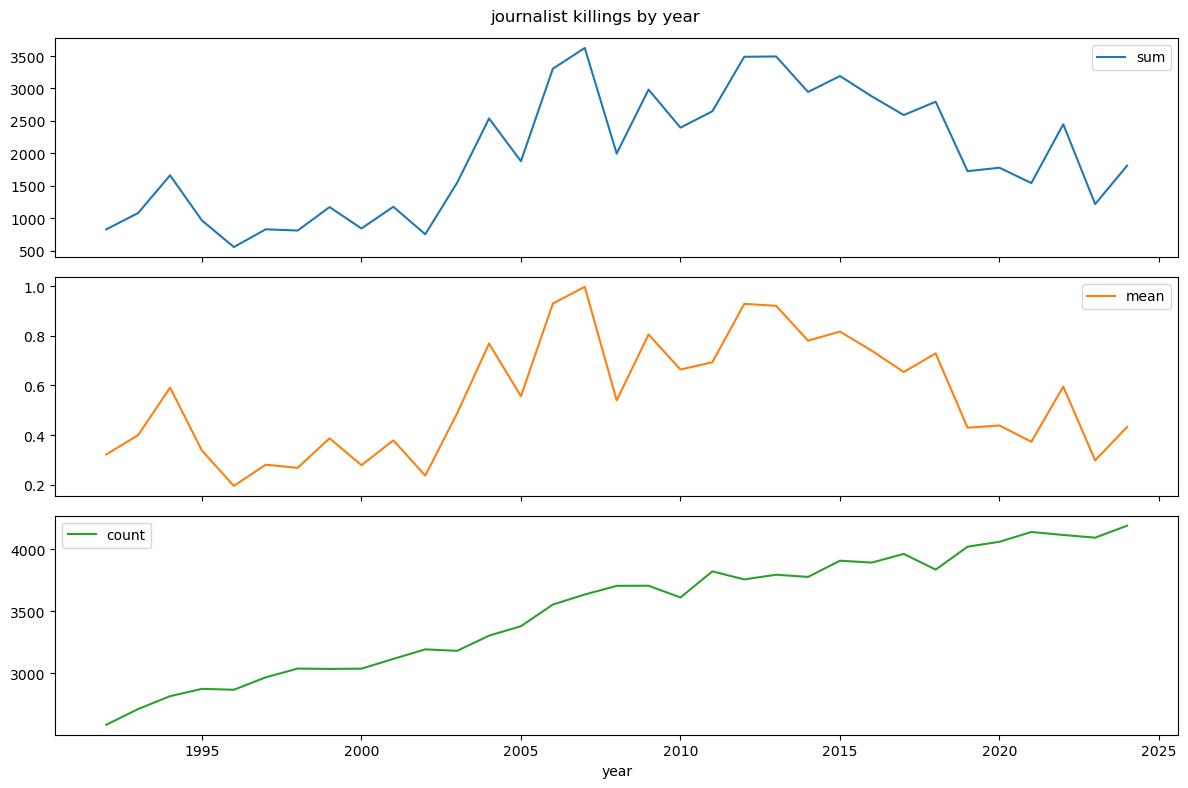

In [10]:
df.groupby('year')['journalist_killings'].agg(['sum', 'mean', 'count']).plot(subplots=True, figsize=(12,8), title='journalist killings by year')
plt.tight_layout()
plt.show()

In [11]:
df.groupby('recipient_iso3')['journalist_killings'].sum().sort_values(ascending=False).head(20)

recipient_iso3
IRQ    10063
SYR     6409
PHL     4918
MEX     4833
PAK     3613
IND     3166
AFG     2989
COL     2564
SOM     2525
BRA     1839
UKR     1371
YEM     1313
DZA     1280
BGD     1207
HND     1063
TUR      842
LKA      787
NGA      741
GTM      682
RWA      649
Name: journalist_killings, dtype: int64

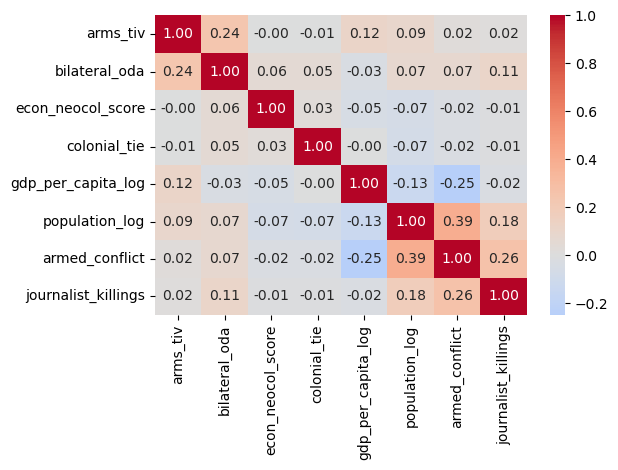

In [12]:
cols = ['arms_tiv', 'bilateral_oda', 'econ_neocol_score', 'colonial_tie', 
        'gdp_per_capita_log', 'population_log', 'armed_conflict', 'journalist_killings']
corr = df[cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.tight_layout()
plt.show()

In [13]:
print(df['econ_neocol_score'].describe())
print(f"\nNon-zero rows: {(df['econ_neocol_score'] > 0).sum():,}")
print(f"Values > 1: {(df['econ_neocol_score'] > 1).sum()}")
print(f"Max: {df['econ_neocol_score'].max():.6f}")

# distribution of non-zero values
df.loc[df['econ_neocol_score'] > 0, 'econ_neocol_score'].describe()

count    8.045900e+04
mean     2.747605e-08
std      2.086036e-07
min      0.000000e+00
25%      6.004668e-10
50%      3.330933e-09
75%      1.451338e-08
max      3.547826e-05
Name: econ_neocol_score, dtype: float64

Non-zero rows: 76,149
Values > 1: 0
Max: 0.000035


count    7.614900e+04
mean     2.903118e-08
std      2.143206e-07
min      3.769142e-16
25%      8.282924e-10
50%      3.907703e-09
75%      1.578441e-08
max      3.547826e-05
Name: econ_neocol_score, dtype: float64

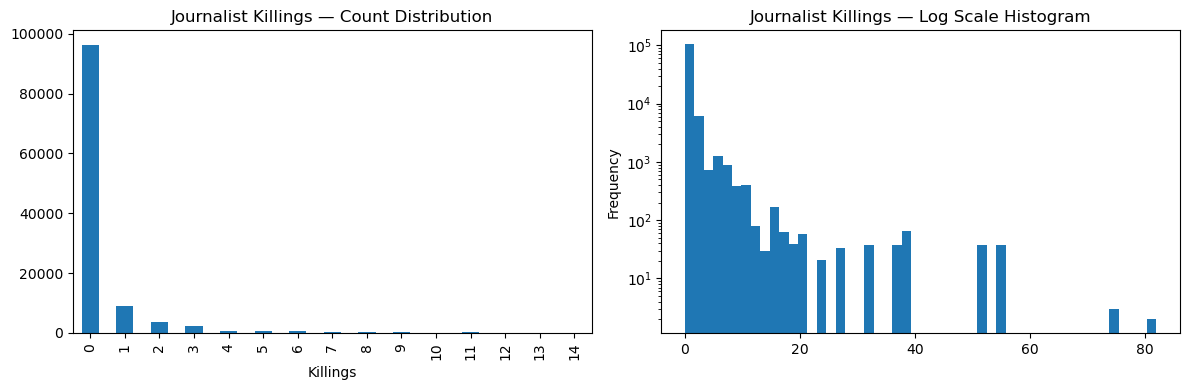

In [14]:
# 1. target variable distribution (log scale)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['journalist_killings'].value_counts().sort_index().head(15).plot(kind='bar', ax=axes[0])
axes[0].set_title('Journalist Killings — Count Distribution')
axes[0].set_xlabel('Killings')
df['journalist_killings'].plot(kind='hist', bins=50, logy=True, ax=axes[1])
axes[1].set_title('Journalist Killings — Log Scale Histogram')
plt.tight_layout()
plt.show()

## Target Variable: Journalist Killings Distribution

83.3% of dyad-year observations record zero killings. The right panel (log scale) 
reveals the long tail — a small number of country-years account for most deaths. 
Variance/mean ratio = 11.6x, confirming overdispersion. This two-process structure 
(zero vs. non-zero, then count intensity) motivates the hurdle model approach.

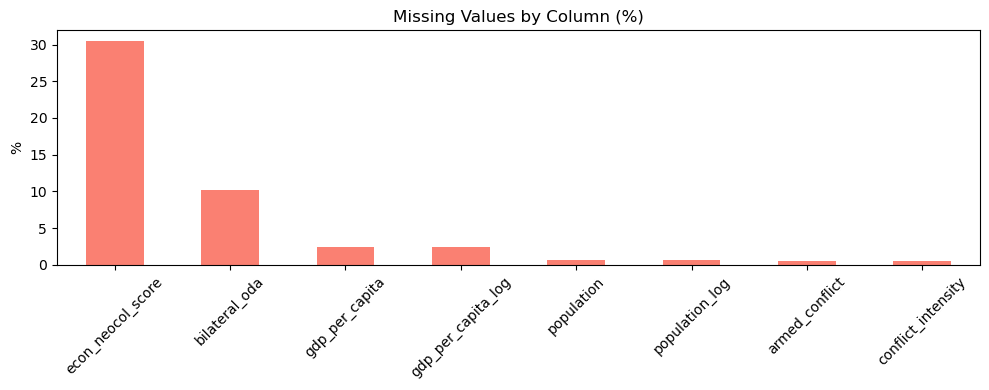

In [15]:
# 2. missingness bar chart
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'pct': missing_pct}).query('pct > 0').sort_values('pct', ascending=False)
missing_df['pct'].plot(kind='bar', color='salmon', figsize=(10, 4))
plt.title('Missing Values by Column (%)')
plt.ylabel('%')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Missingness by Variable

`econ_neocol_score` has the highest missingness (30.4%) — driven by two structural 
gaps: ECI coverage starts 1995 (leaving 1992–1994 as NaN), and ECI covers only 145 
of 213 countries (small island and fragile states excluded). This is NaN by design, 
not a data quality failure. `bilateral_oda` missingness (10.2%) reflects non-donor 
senders (e.g. China, arms exporters) having no ODA records. All other variables are 
under 3% missing.

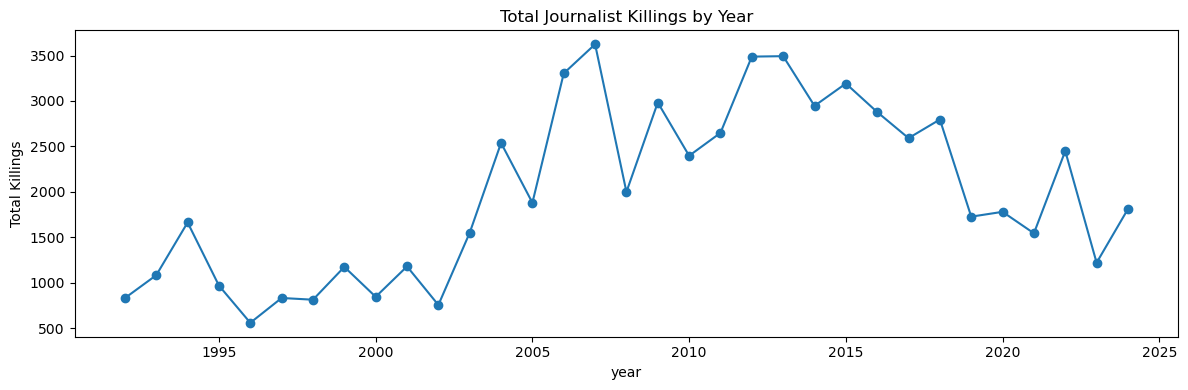

In [16]:
# 3. killings over time
yearly = df.groupby('year')['journalist_killings'].sum()
yearly.plot(figsize=(12, 4), marker='o')
plt.title('Total Journalist Killings by Year')
plt.ylabel('Total Killings')
plt.tight_layout()
plt.show()

## Journalist Killings Over Time

Killings rise sharply from the early 2000s, peaking around 2006–2007 and again 
2012–2015 — corresponding to the Iraq War and Syrian Civil War periods respectively. 
The post-2015 decline partially reflects reduced conflict intensity in those theatres, 
though levels remain elevated. The 2023–2024 uptick is driven significantly by Gaza 
(ISR recipient rows), which will be flagged as a leverage point in modelling.

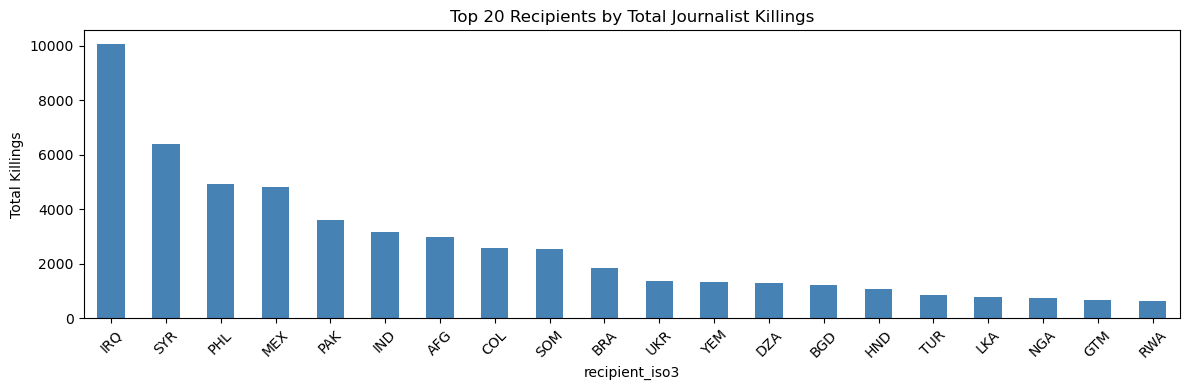

In [17]:
# 4. top 20 recipients
top20 = df.groupby('recipient_iso3')['journalist_killings'].sum().sort_values(ascending=False).head(20)
top20.plot(kind='bar', figsize=(12, 4), color='steelblue')
plt.title('Top 20 Recipients by Total Journalist Killings')
plt.ylabel('Total Killings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Top 20 Recipients by Total Journalist Killings (1992–2024)

IRQ and SYR dominate due to prolonged conflict. PHL, MEX, COL, and HND reflect 
organised crime and cartel-related killings rather than state conflict — an important 
distinction for the theoretical framework. The list is broadly consistent with CPJ's 
own reporting and validates the merge. Note these are counts summed across all 
sender-dyad rows per recipient, not unique incident counts.

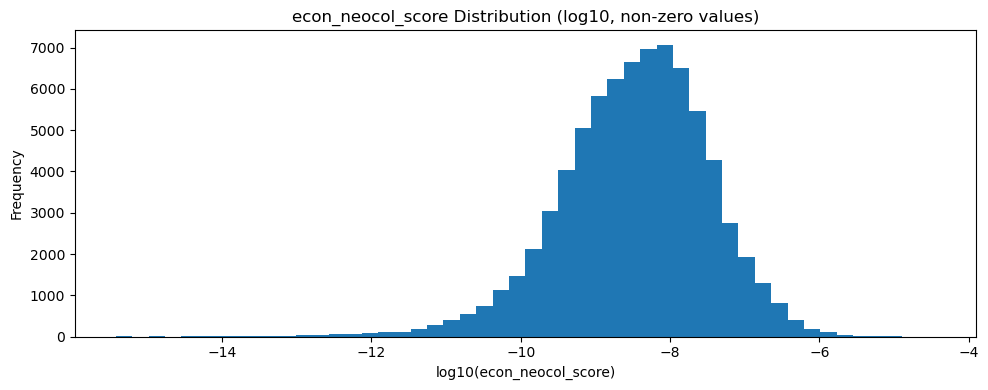

In [18]:
# 5. econ_neocol_score — log transformed for visibility
import numpy as np
nonzero = df.loc[df['econ_neocol_score'] > 0, 'econ_neocol_score']
np.log10(nonzero).plot(kind='hist', bins=50, figsize=(10, 4))
plt.title('econ_neocol_score Distribution (log10, non-zero values)')
plt.xlabel('log10(econ_neocol_score)')
plt.tight_layout()
plt.show()

## econ_neocol_score Distribution (log10, non-zero values)

Raw values cluster between 1e-10 and 1e-6 — a consequence of the formula dividing 
bilateral trade by total GDP (gdp_per_capita × population), which produces very small 
ratios. The distribution is approximately normal on a log10 scale, which is expected 
for a ratio variable of this type. `econ_neocol_score_log` (log1p after ×1e9 rescaling) 
is the version used in all modelling — the raw column is retained for reference only.